In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def get_results(df, feature, loss):
    groupby_features = df.columns.difference(['trial', loss]).tolist()
    avg_df = df.groupby(groupby_features).agg(['mean', 'std'])[loss].reset_index()
    res = avg_df.loc[avg_df.groupby(feature)['mean'].idxmin()].reset_index()
    return res

In [3]:

def plot(gan_df, gt_df, feature, loss, title):
    res_gan_df = get_results(gan_df, feature, loss)
    res_gt_df = get_results(gt_df,feature, loss)


    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 7))

    # Plot for res_gan_df
    axes[0].plot(res_gan_df[feature], res_gan_df['mean'], label='GAN')
    axes[0].fill_between(res_gan_df[feature], res_gan_df['mean'] - res_gan_df['std'], res_gan_df['mean'] + res_gan_df['std'], alpha=0.2)
    axes[0].set_title('GAN HP Search')
    axes[0].set_xlabel(feature)
    axes[0].set_ylabel('mean ' + loss)
    axes[0].legend()

    # Plot for res_gt_df
    axes[1].plot(res_gt_df[feature], res_gt_df['mean'], label='GT', color='orange')
    axes[1].fill_between(res_gt_df[feature], res_gt_df['mean'] - res_gt_df['std'], res_gt_df['mean'] + res_gt_df['std'], alpha=0.2, color='orange')
    axes[1].set_title('GT HP Search')
    axes[1].set_xlabel(feature)
    axes[1].set_ylabel('mean ' + loss)
    axes[1].legend()

    plt.suptitle(title)
    plt.tight_layout()
    plt.savefig(f'figs/{title}_{feature}.pdf')

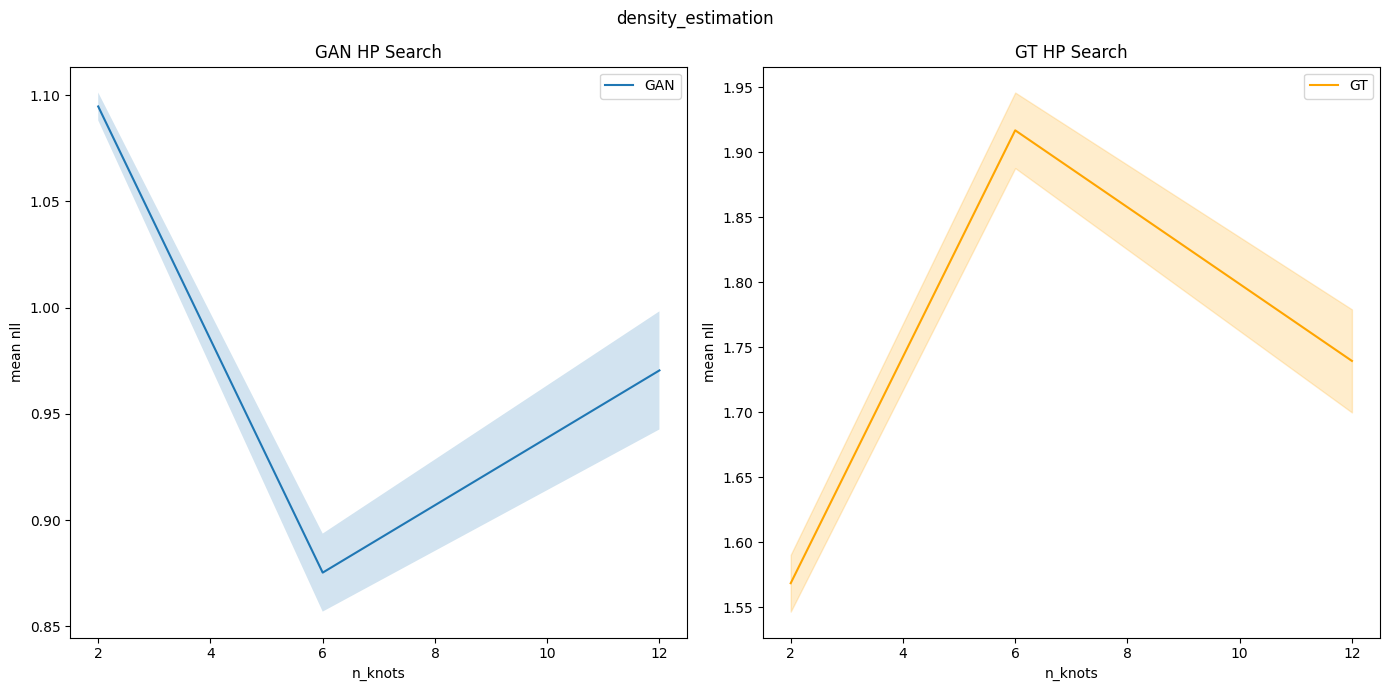

In [15]:
gan_df = pd.read_csv('results/density_estimation_gan_continuous_rate.csv')
gt_df = pd.read_csv('results/density_estimation_gt_continuous_rate.csv')
feature = 'n_knots'
loss = 'nll'
title = 'density_estimation'
plot(gan_df, gt_df, feature, loss, title)

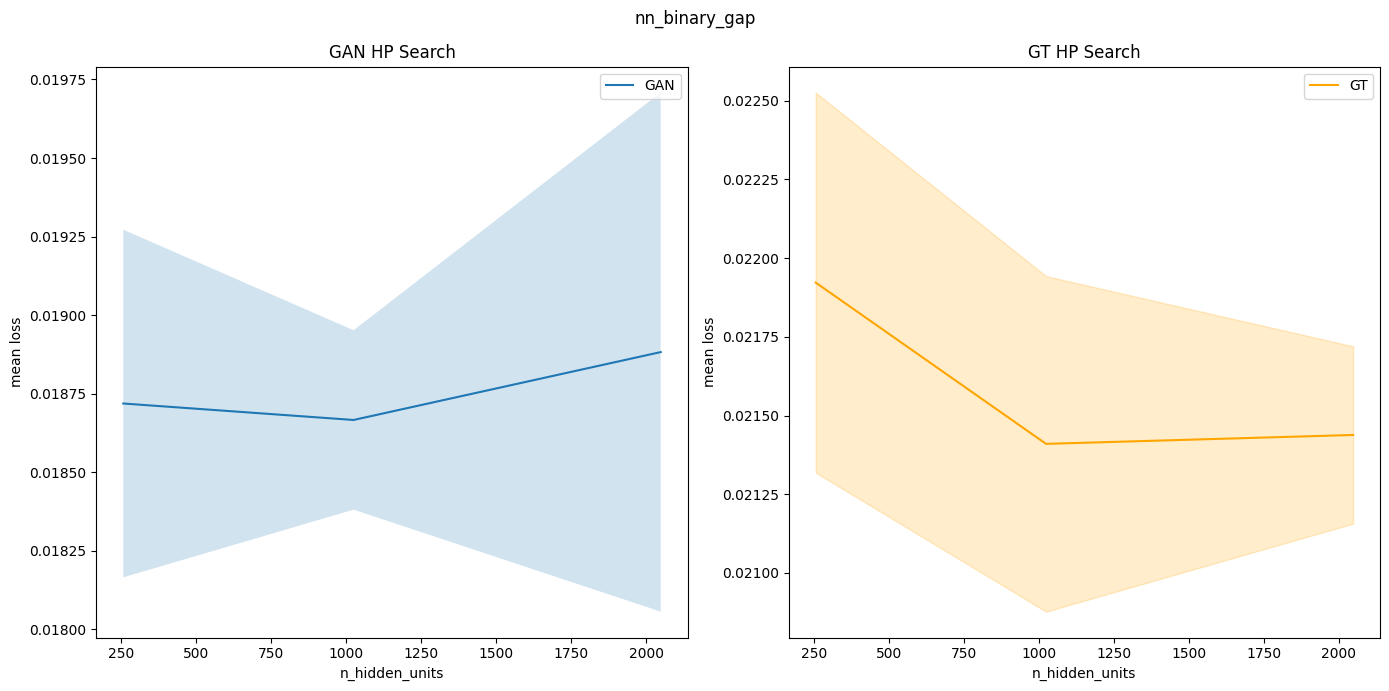

In [10]:
gan_df = pd.read_csv('results/nn_gan_binary_gap.csv')
gt_df = pd.read_csv('results/nn_gt_binary_gap.csv')
feature = 'n_hidden_units'
loss = 'loss'
title = 'nn_binary_gap'
plot(gan_df, gt_df, feature, loss, title)


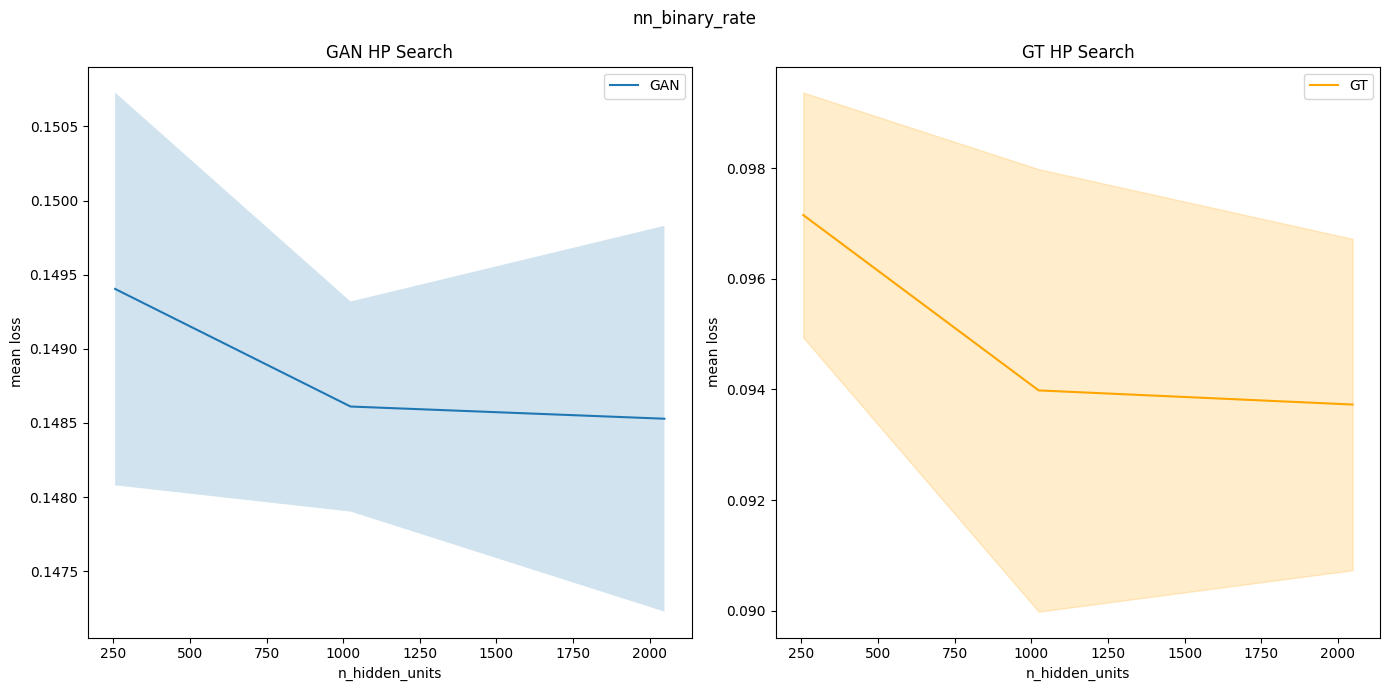

In [12]:
gan_df = pd.read_csv('results/nn_gan_binary_rate.csv')
gt_df = pd.read_csv('results/nn_gt_binary_rate.csv')
feature = 'n_hidden_units'
loss = 'loss'
title = 'nn_binary_rate'
plot(gan_df, gt_df, feature, loss, title)

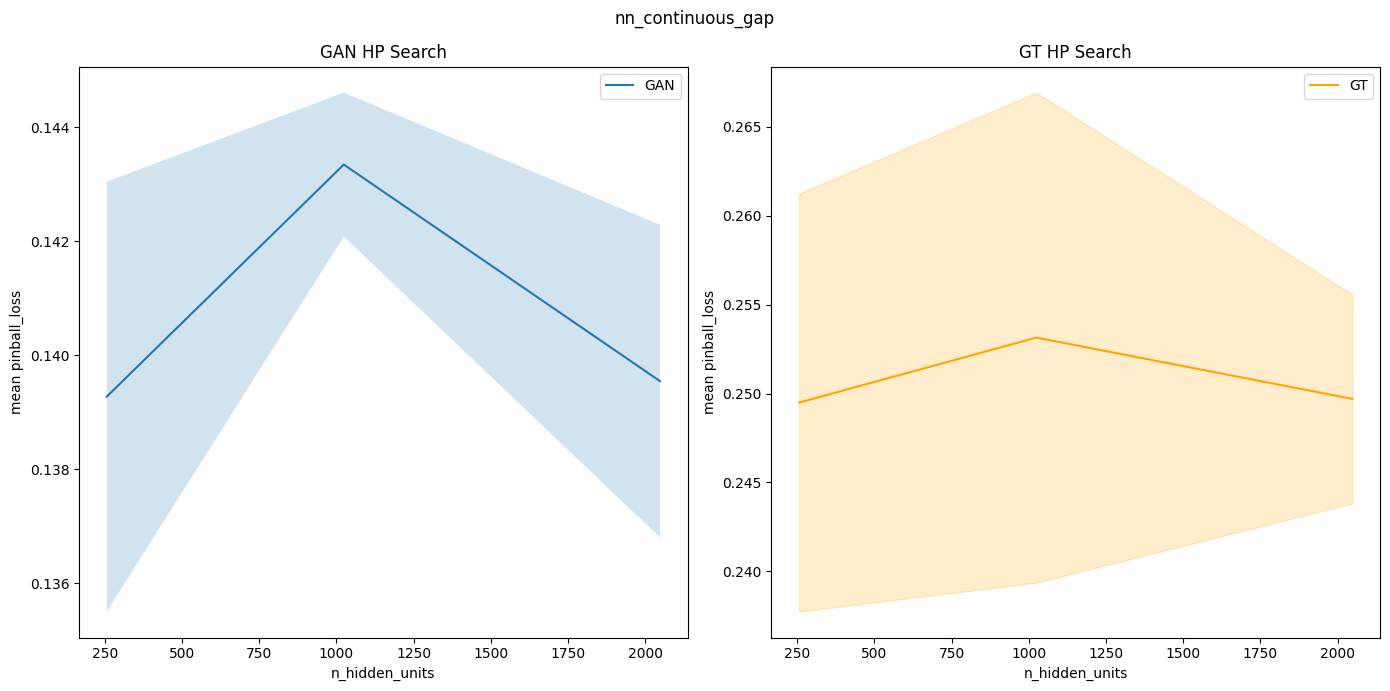

In [11]:
gan_df = pd.read_csv('results/nn_gan_continuous_gap.csv')
gt_df = pd.read_csv('results/nn_gt_continuous_gap.csv')
feature = 'n_hidden_units'
loss = 'pinball_loss'
title = 'nn_continuous_gap'
plot(gan_df, gt_df, feature, loss, title)